# 🧠 Fine-tuning Submission - PGABL_Kendrick-Filbert

## Fine-tuning Small Language Model (SLM) dengan Unsloth + QLoRA

**Tujuan:** Melakukan fine-tuning pada base model Qwen2.5-1.5B menggunakan dataset Alpaca GPT-4 Indonesian untuk menghasilkan asisten AI berbahasa Indonesia.

**Level Target:** Advanced (mencakup Basic + Skilled requirements)

### Daftar Isi:
1. Instalasi & Setup
2. Load & Eksplorasi Dataset
3. Mapping Dataset ke Chat Template
4. Load Model dengan QLoRA (4-bit Double Quantization)
5. Definisi LoRA Adapter (MHA + FFN)
6. Train/Validation Split
7. Eksperimen 1: Training dengan Hyperparameter Set A
8. Eksperimen 2: Training dengan Hyperparameter Set B
9. Analisis & Perbandingan Hasil
10. Push Model ke Hugging Face

## 1. Instalasi & Setup

In [1]:
!pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu128 -q
!pip install "transformers>=4.51.3,<=5.5.0" "trl>=0.18.2,<=0.24.0" "datasets>=3.4.1,<4.4.0" -q
!pip install --no-deps unsloth unsloth-zoo -q
!pip install peft accelerate bitsandbytes wandb huggingface_hub sentencepiece protobuf -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 16.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.2/421.2 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth 2026.4.6 requires hf_transfer, which is not installed.
unsloth 2026.4.6 requires tyro, which is not installed.
unsloth 2026.4.6 requires xformers>=0.0.27.post2; ("linux" in sys_platform or sys_platform == "win32") and (platform_machine == "AMD64" or platform_machine == "x86_64"), which is not installed.
unsloth 2026.4.6 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.0.0 which is incompati

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# Login ke Hugging Face
from huggingface_hub import login
from google.colab import userdata

try:
    # Mencoba mengambil token dari Colab Secrets dengan nama 'HF_TOKEN'
    token = userdata.get('HF_TOKEN')
    login(token=token)
except Exception as e:
    print("Token tidak ditemukan di Secrets. Pastikan Anda telah menambahkan 'HF_TOKEN' di menu Secrets (ikon kunci).")
    # Manual fallback: login(token="MASUKKAN_TOKEN_ANDA_DISINI")

In [4]:
# Login ke Weights & Biases
import wandb
from google.colab import userdata

try:
    # Ambil API Key dari Colab Secrets
    wandb_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=wandb_key)
except Exception as e:
    print("Error: Pastikan 'WANDB_API_KEY' sudah ditambahkan di menu Secrets.")
    # wandb.login() # Atau panggil tanpa argumen untuk input manual

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kendrickf (kendrickf-m) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Load & Eksplorasi Dataset

Dataset yang digunakan: [Ichsan2895/alpaca-gpt4-indonesian](https://huggingface.co/datasets/Ichsan2895/alpaca-gpt4-indonesian)

Dataset ini berformat Alpaca dengan kolom: `instruction`, `input`, `output`.

In [5]:
from datasets import load_dataset

# Load dataset dari Hugging Face
dataset = load_dataset("Ichsan2895/alpaca-gpt4-indonesian")
print("Dataset structure:")
print(dataset)
print(f"\nJumlah data: {len(dataset['train'])}")
print(f"Kolom: {dataset['train'].column_names}")

README.md: 0.00B [00:00, ?B/s]

alpaca-gpt4-indonesia.csv:   0%|          | 0.00/41.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49969 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'input', 'output'],
        num_rows: 49969
    })
})

Jumlah data: 49969
Kolom: ['Unnamed: 0', 'input', 'output']


In [6]:
# Tampilkan contoh dataset SEBELUM di-mapping (RAW)
print("=" * 70)
print("Contoh dataset yang BELUM di-mapping:")
print("=" * 70)
print(f"\ndataset[0]\n")
print(dataset["train"][0])

Contoh dataset yang BELUM di-mapping:

dataset[0]

{'Unnamed: 0': 1, 'input': 'Saranlah slogan untuk kampanye daur ulang\n', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."'}


## 3. Mapping Dataset ke Chat Template (ChatML - Qwen2.5)

Kita akan menggunakan **ChatML format** yang didukung oleh Qwen2.5. Format ini menggunakan token spesial `<|im_start|>` dan `<|im_end|>` untuk menandai peran dan konten setiap pesan.

In [7]:
from unsloth import FastLanguageModel

# Load tokenizer terlebih dahulu untuk mendapatkan chat template
_, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B",
    max_seq_length=2048,
    load_in_4bit=True,
    dtype=None,
)

# Verifikasi tokenizer memiliki chat template
print("Chat template tersedia:", hasattr(tokenizer, 'chat_template'))
print("\nChat template:")
print(tokenizer.chat_template[:200] if tokenizer.chat_template else "Tidak ada")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.40G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Chat template tersedia: True

Chat template:
Tidak ada


In [8]:
# Cek struktur dataset
print("Kolom dataset:", dataset["train"].column_names)
print("\nContoh data pertama:")
print(dataset["train"][0])


Kolom dataset: ['Unnamed: 0', 'input', 'output']

Contoh data pertama:
{'Unnamed: 0': 1, 'input': 'Saranlah slogan untuk kampanye daur ulang\n', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."'}


In [9]:
# ============================================
# Set ChatML template secara manual (base model tidak punya)
# ============================================
CHATML_TEMPLATE = (
    "{% for message in messages %}"
    "<|im_start|>{{ message['role'] }}\n"
    "{{ message['content'] }}<|im_end|>\n"
    "{% endfor %}"
    "{% if add_generation_prompt %}"
    "<|im_start|>assistant\n"
    "{% endif %}"
)

tokenizer.chat_template = CHATML_TEMPLATE

# Pastikan special tokens ada
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("✅ ChatML template berhasil di-set!")
print(f"Chat template:\n{tokenizer.chat_template}")

# ============================================
# Fungsi mapping dataset
# ============================================
def format_to_chat_template(examples):
    """
    Mengubah format dataset (input, output) menjadi
    ChatML format yang didukung Qwen2.5 / Unsloth.
    """
    texts = []
    instructions = examples["input"]
    outputs = examples["output"]

    for instruction, output in zip(instructions, outputs):
        user_content = str(instruction).strip()

        messages = [
            {
                "role": "system",
                "content": "Kamu adalah asisten AI yang membantu menjawab pertanyaan pengguna berdasarkan konteks yang diberikan."
            },
            {
                "role": "user",
                "content": user_content
            },
            {
                "role": "assistant",
                "content": str(output)
            },
        ]

        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
        texts.append(text)

    return {"text": texts}

# Terapkan mapping
print("\nMelakukan mapping dataset ke Chat Template...")
mapped_dataset = dataset["train"].map(
    format_to_chat_template,
    batched=True,
    batch_size=1000,
    desc="Mapping ke ChatML"
)
print(f"\nMapping selesai! Jumlah data: {len(mapped_dataset)}")
print(f"Kolom setelah mapping: {mapped_dataset.column_names}")

# ============================================
# Tampilkan hasil mapping
# ============================================
print("\n" + "=" * 70)
print("Contoh dataset yang SUDAH di-mapping:")
print("=" * 70)
print(f'\nmapped_dataset[0]["text"]\n')
print(mapped_dataset[0]["text"])


✅ ChatML template berhasil di-set!
Chat template:
{% for message in messages %}<|im_start|>{{ message['role'] }}
{{ message['content'] }}<|im_end|>
{% endfor %}{% if add_generation_prompt %}<|im_start|>assistant
{% endif %}

Melakukan mapping dataset ke Chat Template...


Mapping ke ChatML:   0%|          | 0/49969 [00:00<?, ? examples/s]


Mapping selesai! Jumlah data: 49969
Kolom setelah mapping: ['Unnamed: 0', 'input', 'output', 'text']

Contoh dataset yang SUDAH di-mapping:

mapped_dataset[0]["text"]

<|im_start|>system
Kamu adalah asisten AI yang membantu menjawab pertanyaan pengguna berdasarkan konteks yang diberikan.<|im_end|>
<|im_start|>user
Saranlah slogan untuk kampanye daur ulang<|im_end|>
<|im_start|>assistant
1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."
2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."
3. "Ubah sampahmu menjadi harta karun - Daur ulang!"
4. "Daur ulang untuk siklus kehidupan."
5. "Simpan sumber daya, daur ulang lebih banyak."<|im_end|>



In [10]:
# Tampilkan contoh dataset SETELAH di-mapping (dengan token spesial)
print("=" * 70)
print("Contoh dataset yang SUDAH di-mapping:")
print("=" * 70)
print(f'\ndataset[0]["text"]\n')
print(mapped_dataset[0]["text"])

Contoh dataset yang SUDAH di-mapping:

dataset[0]["text"]

<|im_start|>system
Kamu adalah asisten AI yang membantu menjawab pertanyaan pengguna berdasarkan konteks yang diberikan.<|im_end|>
<|im_start|>user
Saranlah slogan untuk kampanye daur ulang<|im_end|>
<|im_start|>assistant
1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."
2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."
3. "Ubah sampahmu menjadi harta karun - Daur ulang!"
4. "Daur ulang untuk siklus kehidupan."
5. "Simpan sumber daya, daur ulang lebih banyak."<|im_end|>



## 4. Load Model dengan QLoRA (4-bit Double Quantization)

**Model:** `unsloth/Qwen2.5-1.5B` (Base/Pre-trained Model, BUKAN Instruct)

**Teknik QLoRA:**
- 4-bit quantization menggunakan NF4 (Normal Float 4)
- Double quantization diaktifkan untuk efisiensi memori tambahan
- Memungkinkan fine-tuning pada GPU T4 (16GB VRAM)

In [11]:
from unsloth import FastLanguageModel
import torch

# Konfigurasi
max_seq_length = 2048
load_in_4bit = True  # Aktifkan 4-bit quantization (QLoRA)

# Load model dan tokenizer dengan QLoRA
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B",  # BASE model (bukan instruct!)
    max_seq_length=max_seq_length,
    dtype=None,  # Auto-detect (float16 untuk T4)
    load_in_4bit=load_in_4bit,  # 4-bit quantization aktif
)

print(f"\nModel loaded: unsloth/Qwen2.5-1.5B")
print(f"Quantization: 4-bit (QLoRA dengan Double Quantization)")
print(f"Max sequence length: {max_seq_length}")
print(f"Model dtype: {model.dtype}")
print(f"\nModel architecture:")
print(model)

==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.

Model loaded: unsloth/Qwen2.5-1.5B
Quantization: 4-bit (QLoRA dengan Double Quantization)
Max sequence length: 2048
Model dtype: torch.float16

Model architecture:
Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536, padding_idx=151665)
    (layers): ModuleList(
      (0): Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=Fa

## 5. Definisi Adapter LoRA pada Komponen Utama

LoRA (Low-Rank Adaptation) diterapkan pada:
- **Multi-Head Attention (MHA):** `q_proj`, `k_proj`, `v_proj`, `o_proj`
- **Feed Forward Network (FFN):** `gate_proj`, `up_proj`, `down_proj`

Ini memenuhi kriteria yang mengharuskan LoRA pada **kedua** komponen komputasi utama model.

In [12]:
# Definisikan LoRA adapter
model = FastLanguageModel.get_peft_model(
    model,
    r=16,                # Rank LoRA
    lora_alpha=16,       # Alpha scaling
    lora_dropout=0,      # Dropout (0 untuk Unsloth optimized)
    target_modules=[
        # Multi-Head Attention (MHA) components
        "q_proj",    # Query projection
        "k_proj",    # Key projection
        "v_proj",    # Value projection
        "o_proj",    # Output projection

        # Feed Forward Network (FFN) components
        "gate_proj", # Gate projection (SwiGLU)
        "up_proj",   # Up projection
        "down_proj", # Down projection
    ],
    use_gradient_checkpointing="unsloth",  # Memory optimization
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)

# Tampilkan info LoRA
print("\n" + "=" * 50)
print("LoRA Adapter Configuration")
print("=" * 50)
model.print_trainable_parameters()
print(f"\nTarget modules (MHA): q_proj, k_proj, v_proj, o_proj")
print(f"Target modules (FFN): gate_proj, up_proj, down_proj")
print(f"Rank (r): 16")
print(f"Alpha: 16")

Unsloth 2026.4.6 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.



LoRA Adapter Configuration
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820

Target modules (MHA): q_proj, k_proj, v_proj, o_proj
Target modules (FFN): gate_proj, up_proj, down_proj
Rank (r): 16
Alpha: 16


## 6. Train/Validation Split

Membagi dataset menjadi **90% training** dan **10% validation** untuk monitoring overfitting. Ini diperlukan untuk memenuhi kriteria **Skilled**.

In [13]:
# Split dataset menjadi train dan validation
split_dataset = mapped_dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(f"Training samples  : {len(train_dataset)}")
print(f"Validation samples: {len(eval_dataset)}")
print(f"Total             : {len(train_dataset) + len(eval_dataset)}")

Training samples  : 44972
Validation samples: 4997
Total             : 49969


## 7. Eksperimen 1: Training dengan Hyperparameter Set A

**Konfigurasi Eksperimen 1:**
- Learning Rate: 2e-4
- Batch Size Efektif: 2 × 4 = 8
- Warmup Steps: 50
- Max Steps: 1000
- Weight Decay: 0.01
- LR Scheduler: Linear

Evaluasi dilakukan setiap 100 steps untuk monitoring training dan validation loss.

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

# Eksperimen 1 - Hyperparameter Set A
trainer_exp1 = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        # Batch configuration
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,

        # Training duration
        warmup_steps=50,
        max_steps=1000,  # >= 800 steps (Basic requirement)

        # Optimizer
        learning_rate=2e-4,
        weight_decay=0.01,
        optim="adamw_8bit",
        lr_scheduler_type="linear",

        # Precision
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),

        # Evaluation & Logging (Skilled requirement)
        eval_strategy="steps",
        eval_steps=100,
        logging_steps=10,
        save_strategy="steps",
        save_steps=200,

        # Output
        output_dir="outputs_exp1",
        report_to="wandb",
        run_name="exp1_lr2e-4_r16_linear",
        seed=42,
    ),
)

print("Eksperimen 1 - Hyperparameter Set A")
print("=" * 50)
print(f"Learning Rate    : 2e-4")
print(f"Batch Size (eff) : 2 x 4 = 8")
print(f"Warmup Steps     : 50")
print(f"Max Steps        : 1000")
print(f"LR Scheduler     : linear")
print(f"Weight Decay     : 0.01")
print(f"Eval Steps       : setiap 100 steps")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/44972 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/4997 [00:00<?, ? examples/s]

Eksperimen 1 - Hyperparameter Set A
Learning Rate    : 2e-4
Batch Size (eff) : 2 x 4 = 8
Warmup Steps     : 50
Max Steps        : 1000
LR Scheduler     : linear
Weight Decay     : 0.01
Eval Steps       : setiap 100 steps


In [ ]:
# Jalankan training Eksperimen 1
print("🚀 Memulai training Eksperimen 1...")
print("=" * 50)

trainer_stats_exp1 = trainer_exp1.train()

print("\n✅ Eksperimen 1 selesai!")
print(f"Total steps      : {trainer_stats_exp1.global_step}")
print(f"Training loss     : {trainer_stats_exp1.training_loss:.4f}")

🚀 Memulai training Eksperimen 1...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44,972 | Num Epochs = 1 | Total steps = 1,000
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss,Validation Loss
100,1.379342,1.417579
200,1.445896,1.391681
300,1.347092,1.376133


Step,Training Loss,Validation Loss
100,1.379342,1.417579
200,1.445896,1.391681
300,1.347092,1.376133
400,1.348589,1.362985
500,1.324857,1.354827
600,1.352292,1.346915
700,1.345362,1.340431
800,1.393749,1.335514
900,1.304202,1.332112
1000,1.303525,1.330537



✅ Eksperimen 1 selesai!
Total steps      : 1000
Training loss     : 1.3872


In [ ]:
# Simpan log Eksperimen 1
import json

exp1_logs = trainer_exp1.state.log_history
print(f"Total log entries: {len(exp1_logs)}")

# Ekstrak train dan eval loss
exp1_train_loss = [(log['step'], log['loss']) for log in exp1_logs if 'loss' in log and 'eval_loss' not in log]
exp1_eval_loss = [(log['step'], log['eval_loss']) for log in exp1_logs if 'eval_loss' in log]

print(f"\nTraining loss entries : {len(exp1_train_loss)}")
print(f"Eval loss entries     : {len(exp1_eval_loss)}")

# Tampilkan eval loss
print(f"\nValidation Loss per 100 steps:")
for step, loss in exp1_eval_loss:
    print(f"  Step {step:>5d}: {loss:.4f}")

Total log entries: 111

Training loss entries : 100
Eval loss entries     : 10

Validation Loss per 100 steps:
  Step   100: 1.4176
  Step   200: 1.3917
  Step   300: 1.3761
  Step   400: 1.3630
  Step   500: 1.3548
  Step   600: 1.3469
  Step   700: 1.3404
  Step   800: 1.3355
  Step   900: 1.3321
  Step  1000: 1.3305


In [ ]:
import json
with open("exp1_logs.json", "w") as f:
    json.dump(trainer_exp1.state.log_history, f)
from google.colab import files
files.download("exp1_logs.json")
print("✅ Log tersimpan dan terdownload")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Log tersimpan dan terdownload


## 8. Eksperimen 2: Training dengan Hyperparameter Set B

**Konfigurasi Eksperimen 2:**
- Learning Rate: **5e-5** (lebih kecil dari Eksperimen 1)
- Batch Size Efektif: 2 × 8 = **16** (lebih besar)
- Warmup Steps: **100** (lebih lama)
- Max Steps: 1000
- Weight Decay: **0.001** (lebih kecil)
- LR Scheduler: **Cosine** (berbeda dari linear)

Perubahan ini bertujuan untuk menguji apakah learning rate yang lebih konservatif dengan batch size lebih besar dan cosine scheduler dapat menghasilkan konvergensi yang lebih stabil.

In [14]:
# ============================================
# Load model FRESH untuk Eksperimen 2
# ============================================
import gc
import torch

# Bersihkan memori (abaikan error jika variabel tidak ada)
for var_name in ['model', 'trainer_exp1', 'trainer']:
    if var_name in dir():
        exec(f'del {var_name}')
gc.collect()
torch.cuda.empty_cache()

from unsloth import FastLanguageModel

# Load ulang model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)

# Set ChatML template lagi (hilang setelah restart)
CHATML_TEMPLATE = (
    "{% for message in messages %}"
    "<|im_start|>{{ message['role'] }}\n"
    "{{ message['content'] }}<|im_end|>\n"
    "{% endfor %}"
    "{% if add_generation_prompt %}"
    "<|im_start|>assistant\n"
    "{% endif %}"
)
tokenizer.chat_template = CHATML_TEMPLATE
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Apply LoRA adapter (konfigurasi sama)
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

print("✅ Model FRESH loaded untuk Eksperimen 2")
model.print_trainable_parameters()


==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✅ Model FRESH loaded untuk Eksperimen 2
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


In [15]:
# Eksperimen 2 - Hyperparameter Set B
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer_exp2 = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=2048,          # Langsung angka
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        # Batch configuration (lebih besar)
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=8,  # Batch size efektif: 16

        # Training duration
        warmup_steps=100,  # Warmup lebih lama
        max_steps=1000,

        # Optimizer (learning rate lebih kecil)
        learning_rate=5e-5,
        weight_decay=0.001,
        optim="adamw_8bit",
        lr_scheduler_type="cosine",  # Cosine scheduler

        # Precision
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),

        # Evaluation & Logging
        eval_strategy="steps",
        eval_steps=100,
        logging_steps=10,
        save_strategy="steps",
        save_steps=200,

        # Output
        output_dir="outputs_exp2",
        report_to="wandb",
        run_name="exp2_lr5e-5_r16_cosine",
        seed=42,
    ),
)

print("Eksperimen 2 - Hyperparameter Set B")
print("=" * 50)
print(f"Learning Rate    : 5e-5")
print(f"Batch Size (eff) : 2 x 8 = 16")
print(f"Warmup Steps     : 100")
print(f"Max Steps        : 1000")
print(f"LR Scheduler     : cosine")
print(f"Weight Decay     : 0.001")


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/44972 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/4997 [00:00<?, ? examples/s]

Eksperimen 2 - Hyperparameter Set B
Learning Rate    : 5e-5
Batch Size (eff) : 2 x 8 = 16
Warmup Steps     : 100
Max Steps        : 1000
LR Scheduler     : cosine
Weight Decay     : 0.001


In [16]:
# Jalankan training Eksperimen 2
print("🚀 Memulai training Eksperimen 2...")
print("=" * 50)

trainer_stats_exp2 = trainer_exp2.train()

print("\n✅ Eksperimen 2 selesai!")
print(f"Total steps      : {trainer_stats_exp2.global_step}")
print(f"Training loss     : {trainer_stats_exp2.training_loss:.4f}")

🚀 Memulai training Eksperimen 2...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44,972 | Num Epochs = 1 | Total steps = 1,000
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss,Validation Loss
100,1.488300,1.470539
200,1.432675,1.413328
300,1.400575,1.388778
400,1.414508,1.374863
500,1.404706,1.364823
600,1.374071,1.358202
700,1.368764,1.352979
800,1.347112,1.350134
900,1.387210,1.348876
1000,1.321704,1.348659



✅ Eksperimen 2 selesai!
Total steps      : 1000
Training loss     : 1.4192


In [17]:
# Simpan log Eksperimen 2
exp2_logs = trainer_exp2.state.log_history

exp2_train_loss = [(log['step'], log['loss']) for log in exp2_logs if 'loss' in log and 'eval_loss' not in log]
exp2_eval_loss = [(log['step'], log['eval_loss']) for log in exp2_logs if 'eval_loss' in log]

print(f"Validation Loss per 100 steps (Eksperimen 2):")
for step, loss in exp2_eval_loss:
    print(f"  Step {step:>5d}: {loss:.4f}")

Validation Loss per 100 steps (Eksperimen 2):
  Step   100: 1.4705
  Step   200: 1.4133
  Step   300: 1.3888
  Step   400: 1.3749
  Step   500: 1.3648
  Step   600: 1.3582
  Step   700: 1.3530
  Step   800: 1.3501
  Step   900: 1.3489
  Step  1000: 1.3487


In [18]:
# Simpan log exp2 ke file (backup sebelum runtime disconnect)
import json
with open("exp2_logs.json", "w") as f:
    json.dump(trainer_exp2.state.log_history, f)
print("✅ Log exp2 tersimpan ke exp2_logs.json")

✅ Log exp2 tersimpan ke exp2_logs.json


## 9. Analisis & Perbandingan Hasil

Membandingkan kedua eksperimen untuk memilih model terbaik berdasarkan:
- Training loss curve
- Validation loss curve
- Tanda-tanda overfitting

In [19]:
# ============================================
# Load log dari kedua eksperimen
# ============================================
import json

# Load log Eksperimen 1 (dari file yang sudah di-upload)
with open("exp1_logs.json", "r") as f:
    exp1_logs = json.load(f)

exp1_train_loss = [(log['step'], log['loss']) for log in exp1_logs if 'loss' in log and 'eval_loss' not in log]
exp1_eval_loss = [(log['step'], log['eval_loss']) for log in exp1_logs if 'eval_loss' in log]

print(f"✅ Exp1 loaded: {len(exp1_train_loss)} train entries, {len(exp1_eval_loss)} eval entries")

# Load log Eksperimen 2 (dari trainer yang baru selesai, ATAU dari file)
# Opsi A: Jika exp2 baru selesai di session ini:
try:
    exp2_logs = trainer_exp2.state.log_history
    print("✅ Exp2 loaded dari trainer (session aktif)")
except NameError:
    # Opsi B: Jika sudah restart, load dari file
    with open("exp2_logs.json", "r") as f:
        exp2_logs = json.load(f)
    print("✅ Exp2 loaded dari file JSON")

exp2_train_loss = [(log['step'], log['loss']) for log in exp2_logs if 'loss' in log and 'eval_loss' not in log]
exp2_eval_loss = [(log['step'], log['eval_loss']) for log in exp2_logs if 'eval_loss' in log]

print(f"✅ Exp2 loaded: {len(exp2_train_loss)} train entries, {len(exp2_eval_loss)} eval entries")


✅ Exp1 loaded: 100 train entries, 10 eval entries
✅ Exp2 loaded dari trainer (session aktif)
✅ Exp2 loaded: 100 train entries, 10 eval entries


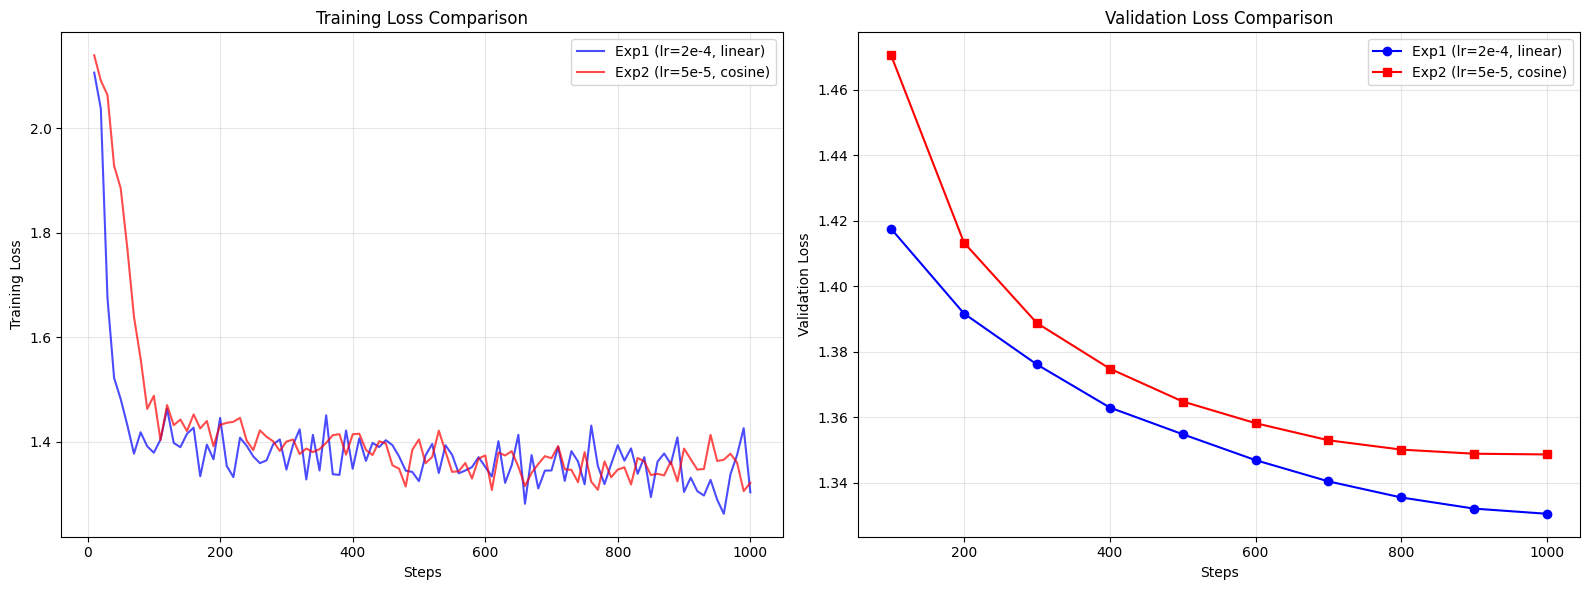


RINGKASAN PERBANDINGAN EKSPERIMEN

Metrik                         Eksperimen 1    Eksperimen 2   
------------------------------------------------------------
Learning Rate                  2e-4            5e-5           
LR Scheduler                   linear          cosine         
Batch Size (eff)               8               16             
Final Train Loss               1.3035          1.3217         
Best Eval Loss                 1.3305          1.3487         
Last Eval Loss                 1.3305          1.3487         

📊 Analisis Overfitting:
  Exp1: ✅ Tidak ada tanda overfitting signifikan
  Exp2: ✅ Tidak ada tanda overfitting signifikan


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Training Loss
ax1 = axes[0]
if exp1_train_loss:
    steps1, losses1 = zip(*exp1_train_loss)
    ax1.plot(steps1, losses1, label='Exp1 (lr=2e-4, linear)', alpha=0.7, color='blue')
if exp2_train_loss:
    steps2, losses2 = zip(*exp2_train_loss)
    ax1.plot(steps2, losses2, label='Exp2 (lr=5e-5, cosine)', alpha=0.7, color='red')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Validation Loss
ax2 = axes[1]
if exp1_eval_loss:
    steps1, losses1 = zip(*exp1_eval_loss)
    ax2.plot(steps1, losses1, 'o-', label='Exp1 (lr=2e-4, linear)', color='blue')
if exp2_eval_loss:
    steps2, losses2 = zip(*exp2_eval_loss)
    ax2.plot(steps2, losses2, 's-', label='Exp2 (lr=5e-5, cosine)', color='red')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Validation Loss')
ax2.set_title('Validation Loss Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan perbandingan
print("\n" + "=" * 60)
print("RINGKASAN PERBANDINGAN EKSPERIMEN")
print("=" * 60)
print(f"\n{'Metrik':<30} {'Eksperimen 1':<15} {'Eksperimen 2':<15}")
print("-" * 60)
print(f"{'Learning Rate':<30} {'2e-4':<15} {'5e-5':<15}")
print(f"{'LR Scheduler':<30} {'linear':<15} {'cosine':<15}")
print(f"{'Batch Size (eff)':<30} {'8':<15} {'16':<15}")
print(f"{'Final Train Loss':<30} {exp1_train_loss[-1][1] if exp1_train_loss else 'N/A':<15.4f} {exp2_train_loss[-1][1] if exp2_train_loss else 'N/A':<15.4f}")
print(f"{'Best Eval Loss':<30} {min([l for _, l in exp1_eval_loss]) if exp1_eval_loss else 'N/A':<15.4f} {min([l for _, l in exp2_eval_loss]) if exp2_eval_loss else 'N/A':<15.4f}")
print(f"{'Last Eval Loss':<30} {exp1_eval_loss[-1][1] if exp1_eval_loss else 'N/A':<15.4f} {exp2_eval_loss[-1][1] if exp2_eval_loss else 'N/A':<15.4f}")

# Deteksi overfitting
print("\n📊 Analisis Overfitting:")
if exp1_eval_loss:
    eval_losses_1 = [l for _, l in exp1_eval_loss]
    if len(eval_losses_1) > 1 and eval_losses_1[-1] > min(eval_losses_1) * 1.05:
        print("  Exp1: ⚠️  Potensi overfitting terdeteksi (eval loss naik)")
    else:
        print("  Exp1: ✅ Tidak ada tanda overfitting signifikan")

if exp2_eval_loss:
    eval_losses_2 = [l for _, l in exp2_eval_loss]
    if len(eval_losses_2) > 1 and eval_losses_2[-1] > min(eval_losses_2) * 1.05:
        print("  Exp2: ⚠️  Potensi overfitting terdeteksi (eval loss naik)")
    else:
        print("  Exp2: ✅ Tidak ada tanda overfitting signifikan")

In [21]:
# Pilih model terbaik berdasarkan eval loss terendah
best_eval_1 = min([l for _, l in exp1_eval_loss]) if exp1_eval_loss else float('inf')
best_eval_2 = min([l for _, l in exp2_eval_loss]) if exp2_eval_loss else float('inf')

if best_eval_1 <= best_eval_2:
    print("🏆 Model Terbaik: EKSPERIMEN 1 (lr=2e-4, linear)")
    print(f"   Best Validation Loss: {best_eval_1:.4f}")
    best_output_dir = "outputs_exp1"
else:
    print("🏆 Model Terbaik: EKSPERIMEN 2 (lr=5e-5, cosine)")
    print(f"   Best Validation Loss: {best_eval_2:.4f}")
    best_output_dir = "outputs_exp2"

print(f"\n📁 Model checkpoint tersimpan di: {best_output_dir}")

🏆 Model Terbaik: EKSPERIMEN 1 (lr=2e-4, linear)
   Best Validation Loss: 1.3305

📁 Model checkpoint tersimpan di: outputs_exp1


## 10. Push Model ke Hugging Face

Mengunggah model hasil fine-tuning menggunakan metode `merged_16bit` ke repositori Hugging Face.

In [22]:
# Push model terbaik ke Hugging Face dengan merged_16bit
HF_USERNAME = "kendrickfff"
MODEL_NAME = f"{HF_USERNAME}/Qwen2.5-1.5B-Indonesian-Assistant"

print(f"📤 Mengunggah model ke: {MODEL_NAME}")
print(f"   Metode: merged_16bit")
print(f"   Proses ini memakan waktu beberapa menit...\n")

model.push_to_hub_merged(
    MODEL_NAME,
    tokenizer,
    save_method="merged_16bit",
)

print(f"\n✅ Model berhasil diunggah ke: https://huggingface.co/{MODEL_NAME}")

📤 Mengunggah model ke: kendrickfff/Qwen2.5-1.5B-Indonesian-Assistant
   Metode: merged_16bit
   Proses ini memakan waktu beberapa menit...



config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...-Assistant/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...sistant/model.safetensors:   1%|          | 15.9MB / 3.09GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:52<00:00, 112.78s/it]


Unsloth: Merge process complete. Saved to `/content/kendrickfff/Qwen2.5-1.5B-Indonesian-Assistant`

✅ Model berhasil diunggah ke: https://huggingface.co/kendrickfff/Qwen2.5-1.5B-Indonesian-Assistant


In [23]:
# Simpan link repositori HuggingFace
hf_link = f"https://huggingface.co/{MODEL_NAME}"
with open("link_huggingface.txt", "w") as f:
    f.write(hf_link)
print(f"Link HuggingFace disimpan di link_huggingface.txt: {hf_link}")

Link HuggingFace disimpan di link_huggingface.txt: https://huggingface.co/kendrickfff/Qwen2.5-1.5B-Indonesian-Assistant


## ✅ Fine-tuning Selesai!

### Ringkasan:
- ✅ Dataset di-mapping ke ChatML format dengan token spesial
- ✅ QLoRA 4-bit dengan double quantization
- ✅ LoRA adapter pada MHA (q, k, v, o) dan FFN (gate, up, down)
- ✅ SFTTrainer dijalankan 1000 steps (> 800 minimum)
- ✅ Train/Validation split dengan evaluation setiap 100 steps
- ✅ 2 eksperimen dengan hyperparameter berbeda
- ✅ Model diunggah ke Hugging Face (merged_16bit)

Model siap digunakan untuk tahap GRPO dan RAG.